## Polymorphism

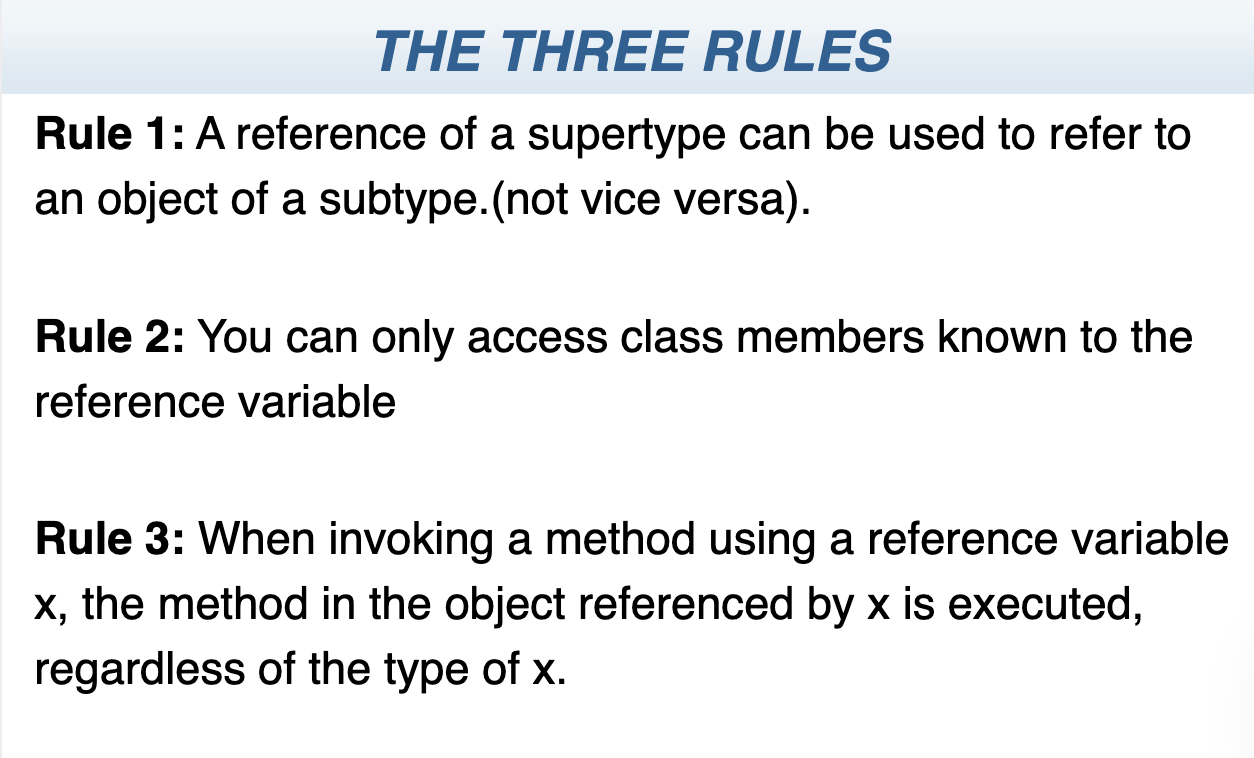

## Rule.1 父类可以用父类自己的reference去作为子类的reference

In [ ]:
public class L3 {
    public static void main(String[] args) {
        father f1 = new son();
        father f2 = new daughter();
        //daughter d1 = new father();这种用法就不可以，子类不能作为父类Obj的reference
    }
}
class father{
}
class son extends father{
}
class daughter extends father{
}

## Rule.2当在父类作为子类的reference并且要用function的时候，这个function必须在父类里存在。只存在子类里的function不存在父类里的function会编译报错
### !! java.util.Objects也就是Object类，默认所有的创建的对象最终都归于Object，都是Object的子类，当情况出现子类有的function但是父类没有的时候就会去看Object有没有function。
### 但是反过来作为父类引用的子类的reference，可以调用子类没有但是父类有的function

In [ ]:
/*这种情况就是当用父类去引用子类并且调用reference时，调用的是父类没有的function，
且Object类也没有的function时就会报错*/
public class L3 {
    public static void main(String[] args) {
        father f1 = new son();
        father f2 = new daughter();
        //daughter d1 = new father();这种用法就不可以，子类不能作为父类Obj的reference
        System.out.println(f1.toString());
        f1.goFather();//这一行会报错，因为违反了Rule.2
    }
}

class father{
    
}
class son extends father{
    public void goFather(){
        System.out.println("goFather");
    }
    public String toString(){
        return "This is son";
    }
}
class daughter extends father{
}

In [ ]:
/*这种情况虽然调用的function父类不存在但是toString这个function是Object类，
也就是所有类的父类中存在的function，所以调用的时候不会报错*/
public class L3 {
    public static void main(String[] args) {
        father f1 = new son();
        father f2 = new daughter();
        //daughter d1 = new father();这种用法就不可以，子类不能作为父类Obj的reference
        System.out.println(f1.toString());
        /*这里不会报错，father作为son的子类没有找到对应的function "toString"
        自己去调用最高的父类Object类了*/
       
    }
}

class father{

}
class son extends father{
    public void goFather(){
        System.out.println("goFather");
    }
    public String toString(){
        return "This is son";
    }
}
class daughter extends father{
}

## Rule.3在父类引用于子类的时候，用父类引用去调用function会先看父类自己有没有这个function，没有的话直接编译错误，有的话就从当前子类一级一级去往上找各个这个子类的上级类有没有这个function知道最上面的父类，也就是创建这个子类是调用的reference的那个父类
### *子类*指的是当前的父类reference指向的子类Object，尽管假如当前子类还有子类，也是从当前指向的子类开始运行

In [ ]:
/*如此的顺序是先看father有没有goName这个functionon，然后有的话就从grandson这个
子类一级一级去向上找，son作为grandson的直接上级类里面就有这个functionon，
所以运行的就是son里面的function而不是father里面的，所以output应该是“son”*/
public class L3 {
    public static void main(String[] args) {
        father f3 = new grandson();
        f3.goName();
    }
}

class father{
    public void goName(){
        System.out.println("father");
    }
}
class son extends father{
    public void goName(){
        System.out.println("son");
    }
    public String toString(){
        return "This is son";
    }
}
class grandson extends son{

}

//output: son